In [538]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, GammaRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures



import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from dmba import AIC_score
from dmba import stepwise_selection

In [539]:
house = pd.read_csv("data/House_Rent_Dataset.csv")
house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [540]:
# BHK: Number of Bedrooms, Hall, Kitchen.
# Rent: Rent of the Houses/Apartments/Flats.
# Size: Size of the Houses/Apartments/Flats in Square Feet.
# Floor: Houses/Apartments/Flats situated in which Floor and Total Number of Floors (Example: Ground out of 2, 3 out of 5, etc.)
# Area Type: Size of the Houses/Apartments/Flats calculated on either Super Area or Carpet Area or Build Area.
# Area Locality: Locality of the Houses/Apartments/Flats.
# City: City where the Houses/Apartments/Flats are Located.
# Furnishing Status: Furnishing Status of the Houses/Apartments/Flats, either it is Furnished or Semi-Furnished or Unfurnished.
# Tenant Preferred: Type of Tenant Preferred by the Owner or Agent.
# Bathroom: Number of Bathrooms.
# Point of Contact: Whom should you contact for more information regarding the Houses/Apartments/Flats.


In [541]:
house["Tenant Preferred"].value_counts()

Tenant Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

In [542]:
house["Point of Contact"].value_counts()

Point of Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

In [543]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [544]:
house["Posted On"].sort_values()

1222    2022-04-13
244     2022-04-23
418     2022-04-23
303     2022-04-23
413     2022-04-23
           ...    
4368    2022-07-10
4126    2022-07-10
4546    2022-07-10
3743    2022-07-10
3552    2022-07-11
Name: Posted On, Length: 4746, dtype: object

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25775/2322696418.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(house.Rent, shade=True, legend=False)


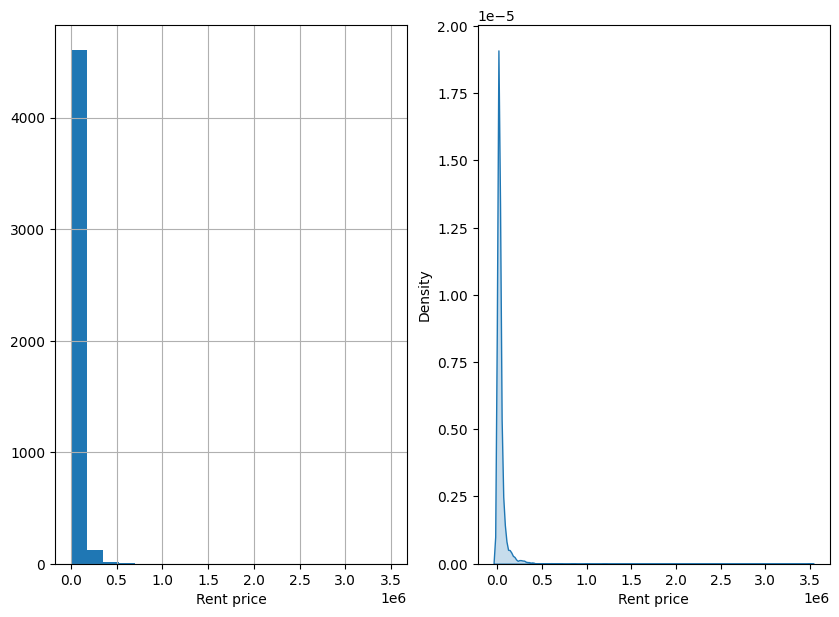

In [545]:
plt.figure(figsize=(10,7))

plt.subplot(121)
house.Rent.hist(density=False, bins=20)
plt.xlabel("Rent price")

plt.subplot(122)
sns.kdeplot(house.Rent, shade=True, legend=False)
plt.xlabel("Rent price")


plt.show()

In [546]:
from datetime import datetime

def day_clasificator(date_string):
    date_object = datetime.strptime(date_string, "%Y-%m-%d")
    return date_object.strftime("%A")


house["day_of_week"] = [day_clasificator(date) for date in house["Posted On"].values]
house.sort_values(by="Posted On")

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week
1222,2022-04-13,3,260000,1800,10 out of 11,Carpet Area,JVPD Scheme,Mumbai,Furnished,Family,4,Contact Agent,Wednesday
244,2022-04-23,2,7000,450,1 out of 3,Carpet Area,safuipara,Kolkata,Furnished,Bachelors,2,Contact Owner,Saturday
418,2022-04-23,1,6500,800,Ground out of 1,Carpet Area,Santragachi,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Saturday
303,2022-04-23,2,20000,700,1 out of 2,Super Area,Salt Lake City Sector 1,Kolkata,Furnished,Bachelors/Family,1,Contact Owner,Saturday
413,2022-04-23,3,36125,1700,Ground out of 2,Super Area,Salt Lake City,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4368,2022-07-10,3,95000,2700,23 out of 30,Carpet Area,Gachibowli,Hyderabad,Furnished,Bachelors,3,Contact Agent,Sunday
4126,2022-07-10,3,50000,2300,2 out of 5,Carpet Area,"Ashok Nagar, Himayath Nagar",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday
4546,2022-07-10,3,67000,2310,3 out of 17,Super Area,Madhapur,Hyderabad,Semi-Furnished,Family,3,Contact Agent,Sunday
3743,2022-07-10,3,15000,1200,2 out of 5,Carpet Area,Madambakkam,Chennai,Unfurnished,Bachelors/Family,2,Contact Agent,Sunday


In [547]:
house["Floor2"] = ["0" if text.split(" ")[0] == "Ground" 
                    else "-1" if text.split(" ")[0] == "Upper" or text.split(" ")[0] == "Lower"
                    else  text.split(" ")[0]
                    for text in house.Floor]
house.Floor2.value_counts()

Floor2
1     1161
2      945
0      927
3      512
4      272
5      164
6       93
7       74
10      67
8       66
9       65
12      47
11      43
15      41
-1      34
14      34
18      26
17      22
16      21
19      16
13      15
20      12
25      12
23       9
24       6
21       6
30       5
34       4
28       4
27       3
26       3
32       3
60       3
65       3
35       3
22       3
48       2
53       2
45       2
36       2
40       2
29       1
50       1
49       1
39       1
46       1
41       1
44       1
33       1
37       1
47       1
43       1
76       1
Name: count, dtype: int64

In [548]:
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
        'Bathroom', 'Point of Contact',"day_of_week", "City"]

X = pd.get_dummies(house[predictors], drop_first=True)
y = house.Rent


house_lm = LinearRegression()
house_lm.fit(X, y)

floor_residuals = pd.DataFrame({
    "floor_num": house.Floor2,
    "residual": y - house_lm.predict(X)
})

floor_residuals


,floor_num,residual
0,0,-22481.151648
1,1,15399.023670
2,1,4968.782694
3,1,5934.218796
4,1,-1061.309082
...,...,...
4741,3,-2410.506284
4742,1,-26694.801170
4743,3,-22975.558288
4744,23,5818.407936


In [549]:
floor_groups = pd.DataFrame([
    {
        "floor": floor,
        "count": len(i),
        "median_residual": i.residual.median()
    }
    for floor, i in floor_residuals.groupby("floor_num")
]).sort_values("median_residual")

floor_groups.sample()

,floor,count,median_residual
36,43,1,152756.032664


In [550]:
floor_groups["cum_count"] = np.cumsum(floor_groups["count"])
floor_groups["floor_group"] = pd.qcut(floor_groups.cum_count, 5, labels=False, retbins=False)
floor_groups

,floor,count,median_residual,cum_count,floor_group
25,30,5,-33227.459022,5,0
9,16,21,-26960.091205,26,0
3,10,67,-26143.176960,93,0
6,13,15,-25715.797319,108,0
42,49,1,-24855.787149,109,0
46,6,93,-24703.007535,202,0
41,48,2,-24228.659172,204,0
52,9,65,-24222.971293,269,0
5,12,47,-23510.378406,316,0
8,15,41,-23396.201309,357,0


In [551]:
to_join = floor_groups[["floor", "floor_group"]].set_index("floor")
house = house.join(to_join, on="Floor2")


In [552]:
house["floor_group"] = house["floor_group"].astype("category")

In [553]:
# Extract total floors
house["Total_floors"] = house["Floor"].apply(lambda x: int(x.split(" ")[-1]) if "out of" in x else 1)

# Extract month from Posted On
house["Month"] = [str(month) for month in pd.to_datetime(house["Posted On"]).dt.month]

# house["Month"] = pd.to_datetime(house["Posted On"]).dt.month

house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week,Floor2,floor_group,Total_floors,Month
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Wednesday,0,2,2,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Friday,1,2,3,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Monday,1,2,3,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Monday,1,2,2,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,Monday,1,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,Wednesday,3,2,5,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,Sunday,1,2,4,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday,3,2,5,7
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,Wednesday,23,2,34,7


In [554]:
def remove_outliers(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & 
                           (df_clean[col] <= Q3 + 1.5*IQR)]
    return df_clean

# Remove outliers from numerical columns
numerical_cols = ["Size", "Rent", 'Total_floors']
house = remove_outliers(house, numerical_cols)

def adjusted_r2(y_actual, y_predict, p):
    print("**Adjusted R2**:",1-(1-r2_score(y_actual, y_predict))*(len(y_actual)-1)/(len(y_actual)-p-1))

house

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,day_of_week,Floor2,floor_group,Total_floors,Month
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,Wednesday,0,2,2,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Friday,1,2,3,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,Monday,1,2,3,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,Monday,1,2,2,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,Monday,1,2,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4740,2022-06-02,2,12000,1350,2 out of 2,Super Area,Old Alwal,Hyderabad,Unfurnished,Bachelors/Family,2,Contact Owner,Thursday,2,2,2,6
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,Wednesday,3,2,5,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,Sunday,1,2,4,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,Sunday,3,2,5,7


In [555]:
house_num = house.select_dtypes(include=["int64"])
house_num

,BHK,Rent,Size,Bathroom,Total_floors
0,2,10000,1100,2,2
1,2,20000,800,1,3
2,2,17000,1000,1,3
3,2,10000,800,1,2
4,2,7500,850,1,2
...,...,...,...,...,...
4740,2,12000,1350,2,2
4741,2,15000,1000,2,5
4742,3,29000,2000,3,4
4743,3,35000,1750,3,5


<Axes: >

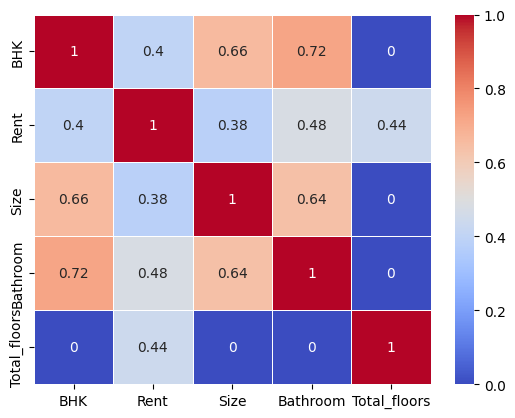

In [556]:
corr_matrix = house_num.corr()

corr_matrix = np.round(corr_matrix, 2)
corr_matrix[np.abs(corr_matrix) < 0.3] = 0
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap="coolwarm")

In [557]:
house_num["higher_15000"] = house_num.Rent > 15000

house_num

,BHK,Rent,Size,Bathroom,Total_floors,higher_15000
0,2,10000,1100,2,2,False
1,2,20000,800,1,3,True
2,2,17000,1000,1,3,True
3,2,10000,800,1,2,False
4,2,7500,850,1,2,False
...,...,...,...,...,...,...
4740,2,12000,1350,2,2,False
4741,2,15000,1000,2,5,False
4742,3,29000,2000,3,4,True
4743,3,35000,1750,3,5,True


<Figure size 1000x700 with 0 Axes>

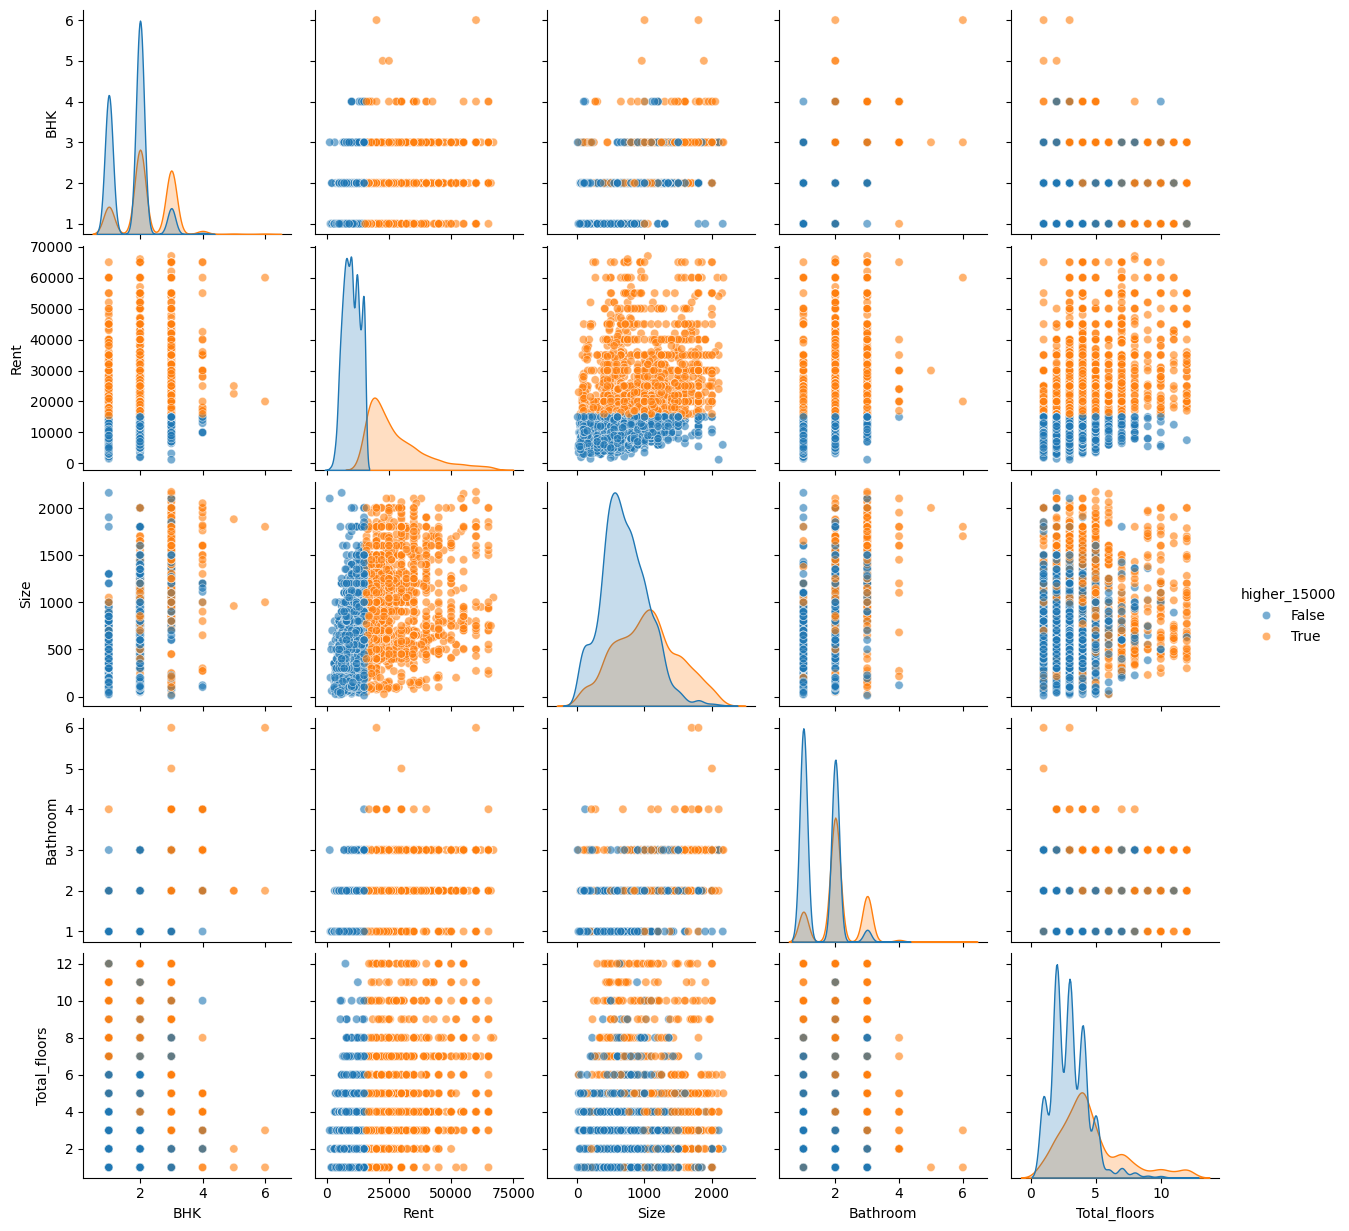

In [558]:
plt.figure(figsize=(10,7))
sns.pairplot(house_num, hue="higher_15000", plot_kws={"alpha": 0.6})
plt.show()

In [559]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month", "City"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Calculate metrics for both sets
def print_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Metrics:")
    print(f"**MSE**: {mse:.2f}")
    print(f"**RMSE**: {rmse:.2f}")
    print(f"**MAE**: {mae:.2f}")
    print(f"**R2 Score**: {r2:.4f}")

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
**MSE**: 44319032.79
**RMSE**: 6657.25
**MAE**: 4741.99
**R2 Score**: 0.6859
**Adjusted R2**: 0.6727865265935423

Cross-validation scores: [0.68144882 0.67007972 0.47966192 0.57718857 0.41892005]
Average CV score: 0.5655 (+/- 0.2066)


In [560]:
X

,BHK,Size,Bathroom,Total_floors,Area Type_Carpet Area,Area Type_Super Area,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,...,floor_group_3,floor_group_4,Month_5,Month_6,Month_7,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,2,1100,2,2,False,True,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
1,2,800,1,3,False,True,True,False,True,False,...,False,False,True,False,False,False,False,False,True,False
2,2,1000,1,3,False,True,True,False,True,False,...,False,False,True,False,False,False,False,False,True,False
3,2,800,1,2,False,True,False,True,True,False,...,False,False,False,False,True,False,False,False,True,False
4,2,850,1,2,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4740,2,1350,2,2,False,True,False,True,True,False,...,False,False,False,True,False,False,False,True,False,False
4741,2,1000,2,5,True,False,True,False,True,False,...,False,False,True,False,False,False,False,True,False,False
4742,3,2000,3,4,False,True,True,False,True,False,...,False,False,True,False,False,False,False,True,False,False
4743,3,1750,3,5,True,False,True,False,True,False,...,False,False,False,False,True,False,False,True,False,False


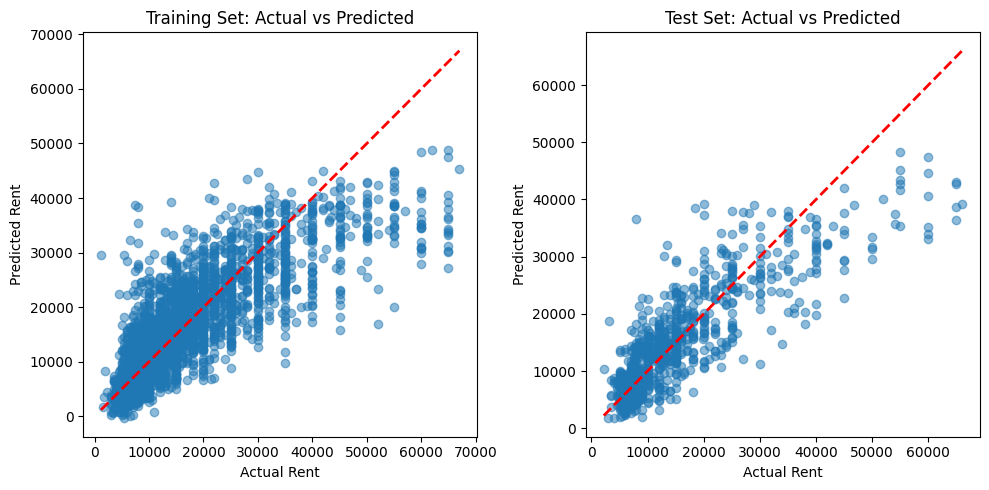

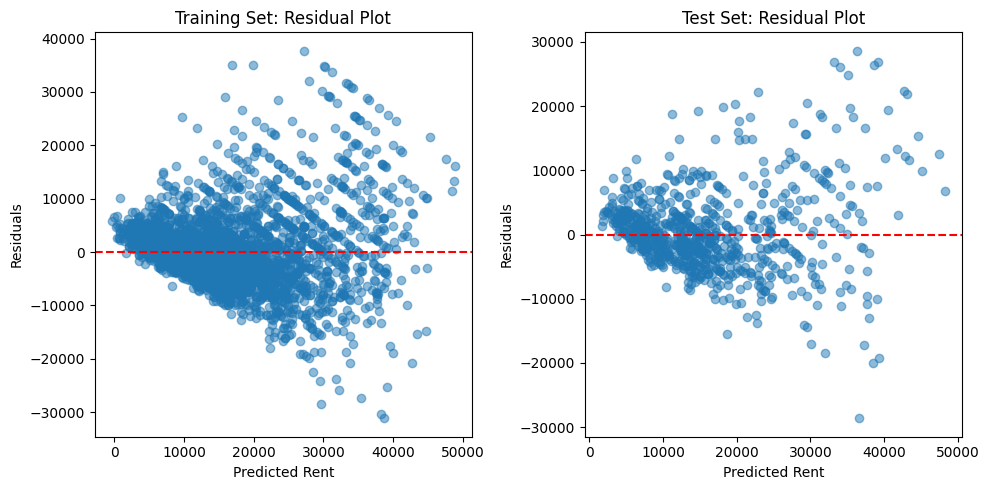

In [561]:
# Visualization of predictions vs actual values
plt.figure(figsize=(10, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Training Set: Actual vs Predicted')

# Test set
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(10, 5))

# Training residuals
plt.subplot(1, 2, 1)
plt.scatter(train_pred, y_train - train_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Training Set: Residual Plot')

# Test residuals
plt.subplot(1, 2, 2)
plt.scatter(test_pred, y_test - test_pred, alpha=0.5)
plt.xlabel('Predicted Rent')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Test Set: Residual Plot')

plt.tight_layout()
plt.show()

In [562]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X_train, y_train))

Lasso(alpha=10)


/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.161e+10, tolerance: 3.846e+07
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.553e+10, tolerance: 3.846e+07
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

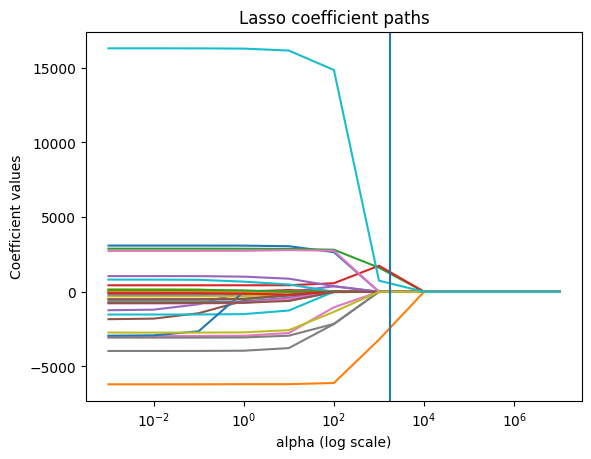

In [563]:

Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

columns = X_train.columns

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X_train, y_train)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X_train, y_train)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Lasso coefficient paths")
plt.show()

In [564]:
print_metrics(y_test, modelCV.predict(X_test), "Lasso regularization")


Lasso regularization Metrics:
**MSE**: 89522947.71
**RMSE**: 9461.66
**MAE**: 6584.62
**R2 Score**: 0.3655


In [565]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,BHK,0.000000
1,Size,9.317414
2,Bathroom,0.000000
3,Total_floors,1896.919429
4,Area Type_Carpet Area,0.000000
5,Area Type_Super Area,-0.000000
6,Furnishing Status_Semi-Furnished,0.000000
7,Furnishing Status_Unfurnished,-0.000000
8,Tenant Preferred_Bachelors/Family,-0.000000
9,Tenant Preferred_Family,0.000000


In [566]:
print(f'Intercept: {model_main.intercept_:.3f}')

pd.DataFrame({
    "name": X_train.columns,
    "coef": model_main.coef_
})

Intercept: 8088.783


,name,coef
0,BHK,3.090130e+03
1,Size,6.487141e+00
2,Bathroom,2.882892e+03
3,Total_floors,4.329016e+02
4,Area Type_Carpet Area,-1.859388e+03
5,Area Type_Super Area,-2.458022e+03
6,Furnishing Status_Semi-Furnished,-2.963468e+03
7,Furnishing Status_Unfurnished,-3.963342e+03
8,Tenant Preferred_Bachelors/Family,-3.090089e+02
9,Tenant Preferred_Family,-1.524679e+03


In [567]:
print_metrics(y_test, modelCV.predict(X_test), "Train regularization")
adjusted_r2(y_test,modelCV.predict(X_test), X.shape[1])


Train regularization Metrics:
**MSE**: 89522947.71
**RMSE**: 9461.66
**MAE**: 6584.62
**R2 Score**: 0.3655
**Adjusted R2**: 0.33903984755287997


In [568]:
print_metrics(y_test, model_main.predict(X_test), "Train main model")
adjusted_r2(y_test,model_main.predict(X_test), X.shape[1])


Train main model Metrics:
**MSE**: 44319032.79
**RMSE**: 6657.25
**MAE**: 4741.99
**R2 Score**: 0.6859
**Adjusted R2**: 0.6727865265935423


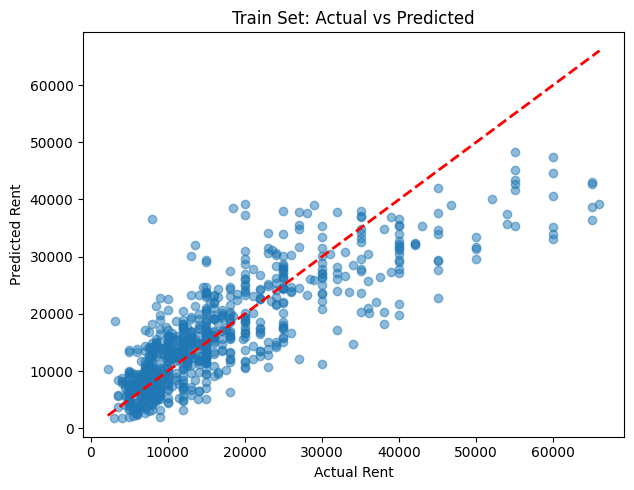

In [569]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Train Set: Actual vs Predicted')

plt.tight_layout()
plt.show()

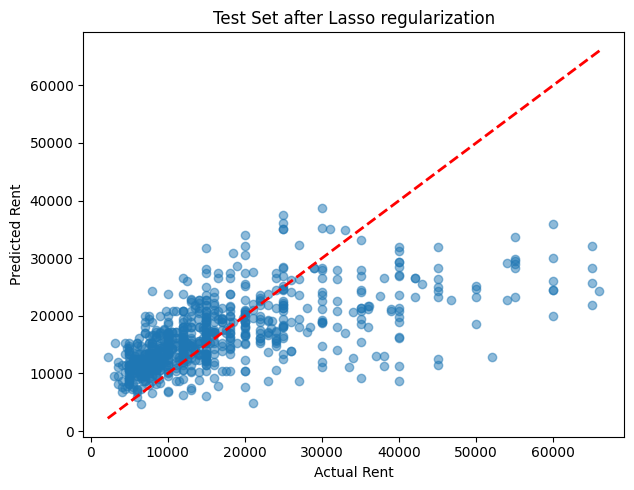

In [570]:
y_pred_lasso = modelCV.predict(X_test)
y_test = y_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_lasso, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent')
plt.ylabel('Predicted Rent')
plt.title('Test Set after Lasso regularization')

plt.tight_layout()
plt.show()

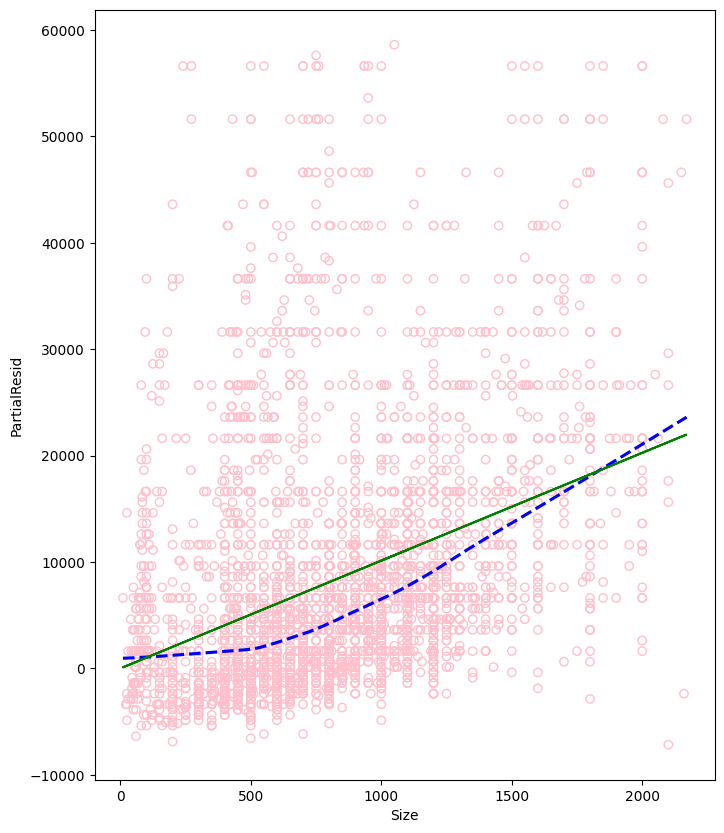

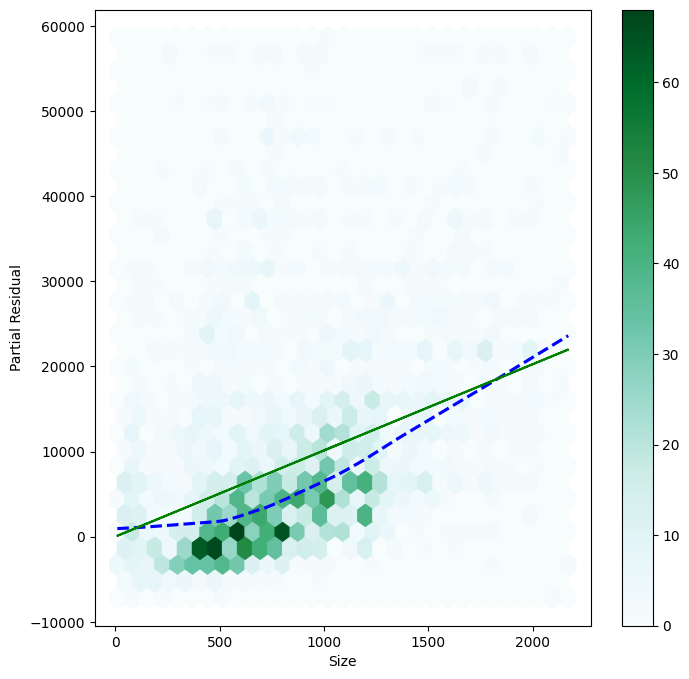

In [571]:
predictor1 = "Size"
X = house[[predictor1]]   # predictor
y = house['Rent']     # response variable

# add intercept
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# get partial residuals
# terms = b_i * X_i (without intercept)
terms = model.params[predictor1] * house[predictor1]
partial_resid = model.resid + terms

# build dataframe for plotting
df = pd.DataFrame({
    predictor1: house[predictor1],
    'Terms': terms,
    'PartialResid': partial_resid
})

# plotting
plt.figure(figsize=(8,10))
plt.scatter(x=df[predictor1], y=df['PartialResid'], facecolors='none', edgecolors='pink')

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')




df.plot.hexbin(x=predictor1, y="PartialResid", gridsize=30, sharex=True, figsize=(8,8))

# smooth fit (like geom_smooth in ggplot2)
sns.regplot(x=predictor1, y='PartialResid', data=df,
            lowess=True, scatter=False, line_kws={'linestyle':'--', 'color':'blue'})

# add linear term line
plt.plot(df[predictor1], df['Terms'], color='green')

%matplotlib inline

plt.xlabel(predictor1)
plt.ylabel("Partial Residual")
plt.show()


Polynomial regression Metrics:
**MSE**: 43019580.62
**RMSE**: 6558.93
**MAE**: 4671.06
**R2 Score**: 0.6951
**Adjusted R2**: 0.6819381925928998


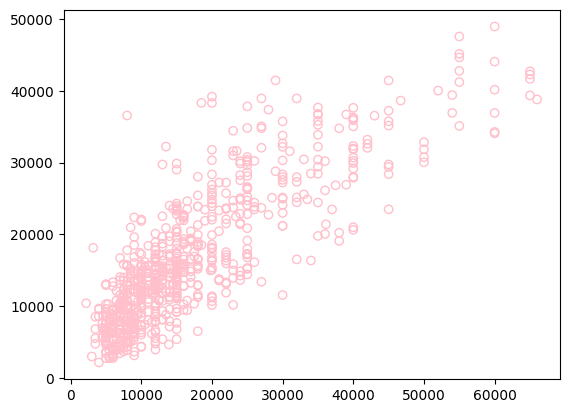

In [572]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month", "City"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X.Size.values.reshape(-1,1))

X = pd.concat([X.loc[:, X.columns != "Size"] , pd.DataFrame(poly_features,index=X.index, columns=["Size", "Size^2"])], axis=1)

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

plt.scatter(y_test, y_pred_poly,facecolors='none', edgecolors='pink')

print_metrics(y_test, y_pred_poly, "Polynomial regression")
adjusted_r2(y_test, y_pred_poly, X.shape[1])

<Axes: xlabel='Size', ylabel='Rent'>

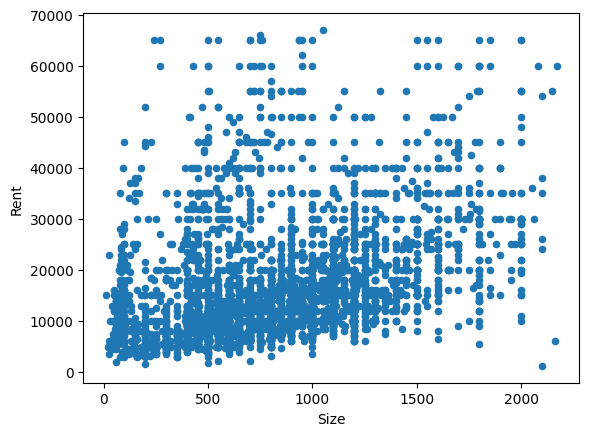

In [573]:
house.plot.scatter(x="Size", y="Rent")

In [574]:
# pd.concat([X_train.loc[:, X_train.columns != "Size"] , pd.DataFrame(poly_features,index=X_train.index, columns=["Size", "Size^2"])], axis=1)

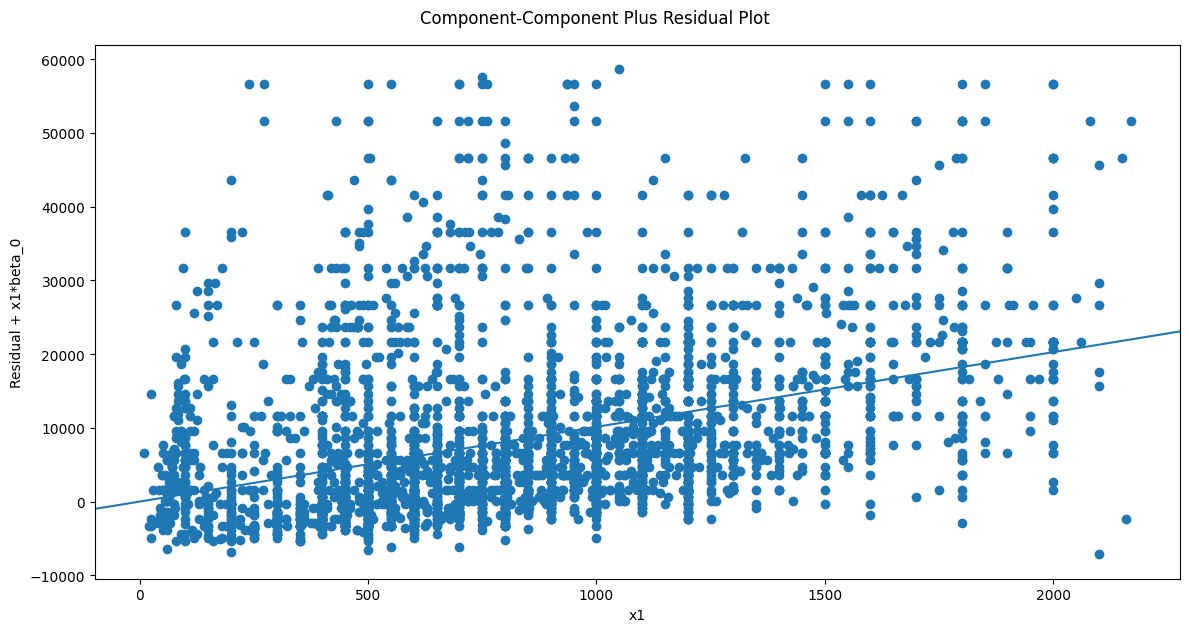

In [575]:
predictors = ['Size']
outcome = "Rent"


house_outlier = sm.OLS(house[outcome].values, house[predictors].assign(const=1).values)
model_OLS = house_outlier.fit()


fig = plt.figure(figsize=(12, 12))
fig = sm.graphics.plot_ccpr_grid(model_OLS, fig=fig)


Test Main model Metrics:
**MSE**: 61851461.04
**RMSE**: 7864.57
**MAE**: 5504.71
**R2 Score**: 0.5616
**Adjusted R2**: 0.5464959277564934

Cross-validation scores: [0.45688903 0.51640172 0.41803544 0.4874207  0.23176099]
Average CV score: 0.4221 (+/- 0.2012)
3455.156419391871


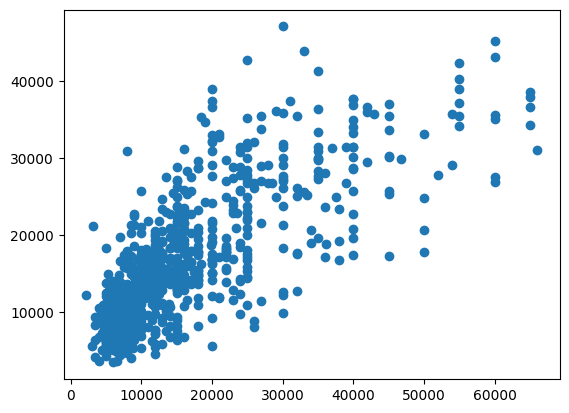

In [576]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)


# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test Main model")
adjusted_r2(y_test, test_pred, X.shape[1])

# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print(test_pred.min())

plt.scatter(x=y_test, y=test_pred)

In [577]:
print(f'Intercept: {model_main.intercept_:.3f}')

pd.DataFrame({
    "name": X_train.columns,
    "coef": model_main.coef_
})

Intercept: 9811.559


,name,coef
0,BHK,1.933893e+03
1,Size,3.321434e+00
2,Bathroom,3.979611e+03
3,Total_floors,1.320831e+03
4,Area Type_Carpet Area,4.538729e+03
5,Area Type_Super Area,3.379260e+03
6,Furnishing Status_Semi-Furnished,-3.599286e+03
7,Furnishing Status_Unfurnished,-4.605835e+03
8,Tenant Preferred_Bachelors/Family,-2.156728e+02
9,Tenant Preferred_Family,-3.103485e+02


In [578]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Month")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Month Metrics:
**MSE**: 62487553.74
**RMSE**: 7904.91
**MAE**: 5528.14
**R2 Score**: 0.5571
**Adjusted R2**: 0.5437226538485381

Cross-validation scores: [0.4538515  0.51504379 0.4181066  0.49485133 0.24838073]
Average CV score: 0.4260 (+/- 0.1899)


In [579]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Floor group")
adjusted_r2(y_test, test_pred, len(predictors))


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Floor group Metrics:
**MSE**: 61973629.83
**RMSE**: 7872.33
**MAE**: 5516.79
**R2 Score**: 0.5608
**Adjusted R2**: 0.5548234393868223

Cross-validation scores: [0.45875477 0.51799915 0.41688421 0.48681968 0.22709705]
Average CV score: 0.4215 (+/- 0.2055)


In [580]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test w/o Total floors")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test w/o Total floors Metrics:
**MSE**: 68936253.73
**RMSE**: 8302.79
**MAE**: 5744.79
**R2 Score**: 0.5114
**Adjusted R2**: 0.49524635203241185

Cross-validation scores: [0.39188962 0.44782347 0.40788083 0.50779912 0.2805021 ]
Average CV score: 0.4072 (+/- 0.1498)


In [581]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
**MSE**: 65621758.32
**RMSE**: 8100.73
**MAE**: 5740.94
**R2 Score**: 0.5349
**Adjusted R2**: 0.5279790271299728

Cross-validation scores: [0.40963185 0.50254392 0.38970144 0.47988084 0.2971566 ]
Average CV score: 0.4158 (+/- 0.1454)


In [582]:
# Create feature matrix X and target vector y
predictors = ['Size', 'Total_floors']
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Fit the model_main
model_main = LinearRegression()
model_main.fit(X_train, y_train)

# Make predictions
train_pred = model_main.predict(X_train)
test_pred = model_main.predict(X_test)

# Print metrics for both training and test sets
print_metrics(y_test, test_pred, "Test")
adjusted_r2(y_test, test_pred, X.shape[1])


# Perform cross-validation
cv_scores = cross_val_score(model_main, X, y, cv=5, scoring='r2')
print("\nCross-validation scores:", cv_scores)
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Test Metrics:
**MSE**: 88188684.34
**RMSE**: 9390.88
**MAE**: 6526.50
**R2 Score**: 0.3750
**Adjusted R2**: 0.37329659227785217

Cross-validation scores: [ 0.27349724  0.37368596  0.17398382  0.3629796  -0.15367374]
Average CV score: 0.2061 (+/- 0.3875)


In [583]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)


model_log = LinearRegression()

y_train_log = np.log1p(y_train)   # log(1 + y), чтобы избежать проблем с нулями
model_log.fit(X_train, y_train_log)

# предсказание
y_pred_log = model_log.predict(X_test)
y_pred = np.expm1(y_pred_log)


print_metrics(y_test, y_pred, "Test w/ log() function")
adjusted_r2(y_test, y_pred, X.shape[1])



Test w/ log() function Metrics:
**MSE**: 66892203.03
**RMSE**: 8178.77
**MAE**: 5336.88
**R2 Score**: 0.5259
**Adjusted R2**: 0.5095364609614803


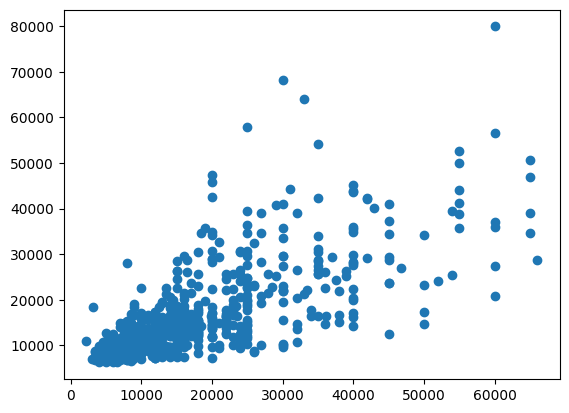

In [584]:
plt.scatter(x=y_test, y=y_pred)

In [585]:

gamma = GammaRegressor(alpha=0, max_iter=100000)
gamma.fit(X_train, y_train)
y_pred_gamma = gamma.predict(X_test)

print_metrics(y_test, y_pred_gamma, "Test w/o Floor group")
adjusted_r2(y_test, y_pred_gamma, X.shape[1])


Test w/o Floor group Metrics:
**MSE**: 68622430.48
**RMSE**: 8283.87
**MAE**: 5506.98
**R2 Score**: 0.5136
**Adjusted R2**: 0.49685017706329404


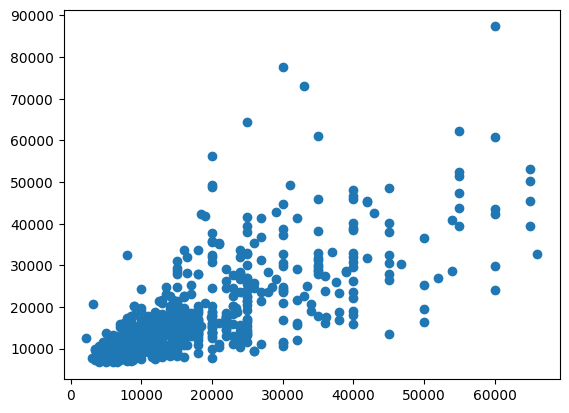

In [586]:
plt.scatter(y_test, y_pred_gamma)

In [587]:
a =np.array([[1,1,1,1],
          [1,-1,2,-3],
          [2,3,1,1],
          [3,-5,-3,1]])

np.linalg.det(a)

np.float64(73.99999999999997)

In [588]:
b = np.array([[-2,1,-4],
              [3,-2,3],
              [-10,-15,8]])

np.linalg.det(b)

np.float64(148.00000000000009)


Polynomial regression Metrics:
**MSE**: 43019580.62
**RMSE**: 6558.93
**MAE**: 4671.06
**R2 Score**: 0.6951
**Adjusted R2**: 0.6819381925928998


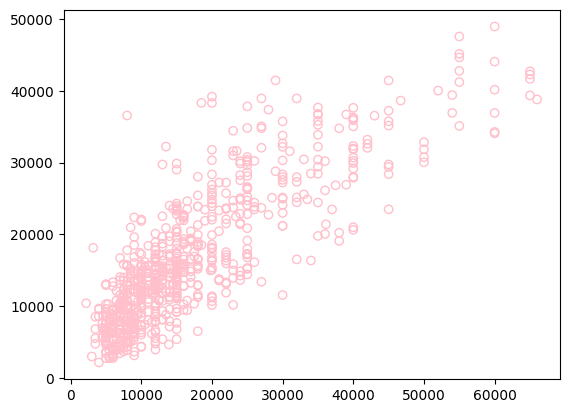

In [589]:
# Create feature matrix X and target vector y
predictors = ['BHK', 'Size', 'Area Type', 'Furnishing Status', 'Tenant Preferred',
              'Bathroom', 'Point of Contact', 'day_of_week', 'floor_group', 'Total_floors',"Month", "City"]
outcome = "Rent"

X = pd.get_dummies(house[predictors], drop_first=True)
y = house[outcome]

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X.Size.values.reshape(-1,1))

X = pd.concat([X.loc[:, X.columns != "Size"] , pd.DataFrame(poly_features,index=X.index, columns=["Size", "Size^2"])], axis=1)

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

plt.scatter(y_test, y_pred_poly,facecolors='none', edgecolors='pink')

print_metrics(y_test, y_pred_poly, "Polynomial regression")
adjusted_r2(y_test, y_pred_poly, X.shape[1])

In [590]:
from sklearn.linear_model import Ridge

alphas = list(np.logspace(-4,8,13))
models = []
coefs = []
alphas

[np.float64(0.0001),
 np.float64(0.001),
 np.float64(0.01),
 np.float64(0.1),
 np.float64(1.0),
 np.float64(10.0),
 np.float64(100.0),
 np.float64(1000.0),
 np.float64(10000.0),
 np.float64(100000.0),
 np.float64(1000000.0),
 np.float64(10000000.0),
 np.float64(100000000.0)]

In [591]:
for alpha1 in alphas:
    model_ridge = Ridge(alpha=alpha1).fit(X_train, y_train)
    models.append(model_ridge)
    coefs.append(model_ridge.coef_)

models.append(model_poly)
coefs.append(model_poly.coef_)
alphas.append("no")


/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.74855e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.74855e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.74855e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.74855e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [592]:
pd.DataFrame(coefs)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,3109.816547,2795.126011,433.320233,-1855.917742,-2437.873835,-2962.228508,-3976.993754,-341.583133,-1487.091685,-3337.673135,...,116.395317,-102.459136,1048.250250,-699.877657,2163.526980,-3250.009328,-2815.521628,16191.690978,0.389314,0.003203
1,3109.804869,2795.131737,433.326235,-1851.992879,-2433.964578,-2962.213041,-3976.972341,-341.577532,-1487.074283,-3334.652933,...,116.386730,-102.465316,1048.241925,-699.889432,2163.507464,-3250.021173,-2815.524094,16191.584439,0.389303,0.003203
2,3109.688401,2795.189273,433.386190,-1813.511562,-2395.638370,-2962.058590,-3976.758811,-341.521940,-1486.900394,-3304.748232,...,116.300223,-102.528361,1048.157906,-700.007071,2163.312094,-3250.140095,-2815.548591,16190.520060,0.389200,0.003203
3,3108.549006,2795.786299,433.980036,-1492.559058,-2076.154470,-2960.532204,-3974.672338,-341.000072,-1485.171361,-3032.734145,...,115.382190,-103.260522,1047.253111,-701.173609,2161.338945,-3251.362828,-2815.780640,16179.959879,0.388112,0.003203
4,3097.997156,2802.218165,439.597389,-403.841235,-998.765328,-2945.867326,-3955.207037,-336.655479,-1468.109237,-1663.498173,...,104.517027,-113.571108,1036.002504,-712.327537,2140.740612,-3263.620247,-2817.824789,16077.365004,0.374508,0.003206
5,3001.078094,2860.013743,492.038929,254.400629,-426.386366,-2806.257400,-3773.353908,-299.200791,-1312.751102,-302.476647,...,10.609069,-203.473333,935.116361,-801.254494,1952.785453,-3354.461688,-2822.490294,15141.161707,0.229033,0.003238
6,2400.311689,3047.107996,869.193416,633.264881,-628.974906,-1844.366603,-2635.588295,-189.012444,-587.911057,-30.753722,...,-210.181206,-369.838074,670.959375,-911.846351,1248.148001,-3371.413576,-2348.730561,9919.415183,-0.463209,0.003403
7,1325.284272,1921.536875,1588.472840,970.006341,-963.785935,-263.563993,-853.896468,-327.860112,4.420779,-2.757768,...,-203.093348,-165.064691,392.856768,-246.367876,619.177122,-1534.595886,-712.773676,2553.388565,-0.758463,0.003907
8,292.063768,408.230390,1206.528864,314.401751,-313.526742,17.537118,-170.542601,-122.299732,33.420560,-0.513222,...,-66.757452,-15.342510,90.842578,-56.906909,121.978390,-242.089968,-123.056680,388.808825,0.039887,0.004616
9,33.333375,50.330440,254.492307,41.906845,-41.827918,5.059030,-23.478175,-16.099469,5.632073,-0.071479,...,-9.426737,-0.997350,11.571387,-10.852691,13.995027,-25.512279,-17.668964,49.661713,0.040160,0.005002


In [593]:
for i,m in enumerate(models):
    print_metrics(y_test, m.predict(X_test), f"Test set \nalpha: {alphas[i]}")
    print_metrics(y_train, m.predict(X_train), f"Train set \nalpha: {alphas[i]}")
    print("-"*25)


Test set 
alpha: 0.0001 Metrics:
**MSE**: 43019577.69
**RMSE**: 6558.93
**MAE**: 4671.06
**R2 Score**: 0.6951

Train set 
alpha: 0.0001 Metrics:
**MSE**: 47717679.85
**RMSE**: 6907.80
**MAE**: 4773.72
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.001 Metrics:
**MSE**: 43019551.43
**RMSE**: 6558.93
**MAE**: 4671.05
**R2 Score**: 0.6951

Train set 
alpha: 0.001 Metrics:
**MSE**: 47717679.86
**RMSE**: 6907.80
**MAE**: 4773.72
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.01 Metrics:
**MSE**: 43019299.64
**RMSE**: 6558.91
**MAE**: 4671.00
**R2 Score**: 0.6951

Train set 
alpha: 0.01 Metrics:
**MSE**: 47717680.90
**RMSE**: 6907.80
**MAE**: 4773.73
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.1 Metrics:
**MSE**: 43017649.96
**RMSE**: 6558.78
**MAE**: 4670.57
**R2 Score**: 0.6951

Train set 
alpha: 0.1 Metrics:
**MSE**: 47717761.44
**RMSE**: 6907.80
**MAE**: 4773.83
**R2 Score**: 0.6281
-------------------------

Test set 
alpha

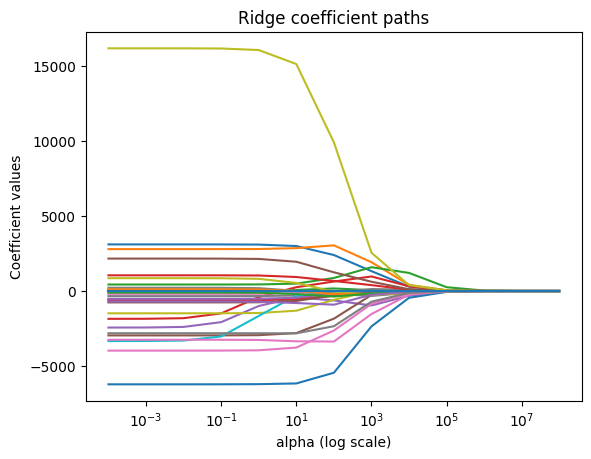

In [610]:

ax = pd.DataFrame(coefs[:-1], index=alphas[:-1], columns=X_train.columns).plot(logx=True, legend=False)
# ax.axvline(modelCV.alpha_)
# ax.set_figure(fig=(15,10))
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Ridge coefficient paths")
ax.set_xscale("log")
# plt.legend()
plt.show()

In [603]:
alphas

[np.float64(0.0001),
 np.float64(0.001),
 np.float64(0.01),
 np.float64(0.1),
 np.float64(1.0),
 np.float64(10.0),
 np.float64(100.0),
 np.float64(1000.0),
 np.float64(10000.0),
 np.float64(100000.0),
 np.float64(1000000.0),
 np.float64(10000000.0),
 np.float64(100000000.0),
 'no']

In [604]:
from sklearn.linear_model import Lasso

alphas_l = list(np.logspace(-4,8,13))
models_l = []
coefs_l = []

for a in alphas_l:
    model_lasso = Lasso(alpha=a).fit(X_train, y_train)
    models_l.append(model_lasso)
    coefs_l.append(model_lasso.coef_)


models_l.append(model_poly)
coefs_l.append(model_poly.coef_)
alphas_l.append("no")
alphas_l

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.143e+10, tolerance: 3.846e+07
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.080e+10, tolerance: 3.846e+07
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations

[np.float64(0.0001),
 np.float64(0.001),
 np.float64(0.01),
 np.float64(0.1),
 np.float64(1.0),
 np.float64(10.0),
 np.float64(100.0),
 np.float64(1000.0),
 np.float64(10000.0),
 np.float64(100000.0),
 np.float64(1000000.0),
 np.float64(10000000.0),
 np.float64(100000000.0),
 'no']

In [605]:
models_l

[Lasso(alpha=np.float64(0.0001)),
 Lasso(alpha=np.float64(0.001)),
 Lasso(alpha=np.float64(0.01)),
 Lasso(alpha=np.float64(0.1)),
 Lasso(alpha=np.float64(1.0)),
 Lasso(alpha=np.float64(10.0)),
 Lasso(alpha=np.float64(100.0)),
 Lasso(alpha=np.float64(1000.0)),
 Lasso(alpha=np.float64(10000.0)),
 Lasso(alpha=np.float64(100000.0)),
 Lasso(alpha=np.float64(1000000.0)),
 Lasso(alpha=np.float64(10000000.0)),
 Lasso(alpha=np.float64(100000000.0)),
 LinearRegression()]

In [606]:
coefs_l[-1]

array([ 3.10981784e+03,  2.79512537e+03,  4.33319566e+02, -1.85635472e+03,
       -2.43830907e+03, -2.96223023e+03, -3.97699613e+03, -3.41583756e+02,
       -1.48709362e+03, -3.33800905e+03, -6.22504377e+03, -5.69186815e+02,
        3.83286624e+01, -6.11846883e+02, -5.20506542e+02, -7.59356953e+02,
       -1.88019344e+02,  2.16643922e+02,  8.56770221e+02, -3.41060513e-13,
       -8.86757334e-12,  1.16396270e+02, -1.02458450e+02,  1.04825117e+03,
       -6.99876349e+02,  2.16352915e+03, -3.25000801e+03, -2.81552135e+03,
        1.61917028e+04,  3.89314874e-01,  3.20322686e-03])

In [607]:
coefs_l[-2]

array([ 0.        ,  0.        ,  0.        ,  0.        , -0.        ,
        0.        , -0.        , -0.        ,  0.        , -0.        ,
       -0.        , -0.        ,  0.        , -0.        ,  0.        ,
        0.        , -0.        ,  0.        , -0.        ,  0.        ,
        0.        , -0.        , -0.        ,  0.        , -0.        ,
        0.        , -0.        , -0.        ,  0.        ,  0.        ,
        0.00494461])

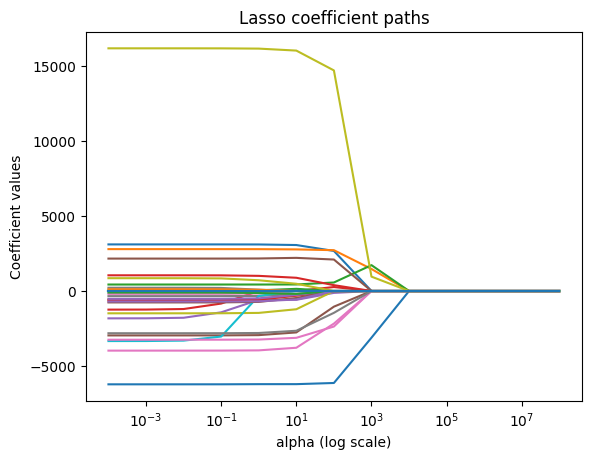

In [611]:
ax = pd.DataFrame(coefs_l[:-1], index=alphas_l[:-1], columns=X_train.columns).plot(logx=True, legend=False)
# ax.axvline(modelCV.alpha_)
# ax.set_figure(fig=(15,10))
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient values")
ax.set_title("Lasso coefficient paths")
# plt.legend()
plt.show()

In [ ]:
results = pd.DataFrame({"alpha": [],
                        "test": [],
                        "train": []})

for i,m in enumerate(models):
    print_metrics(y_test, m.predict(X_test), f"Test set \nalpha: {alphas[i]}")
    print_metrics(y_train, m.predict(X_train), f"Train set \nalpha: {alphas[i]}")
    print("-"*25)
    results.loc[len(results)] = {"alpha": alphas[i],
                                "test": mean_absolute_error(y_test, m.predict(X_test)),
                                "train": mean_absolute_error(y_train, m.predict(X_train))}

results


Test set 
alpha: 0.0001 Metrics:
**MSE**: 43019577.69
**RMSE**: 6558.93
**MAE**: 4671.06
**R2 Score**: 0.6951

Train set 
alpha: 0.0001 Metrics:
**MSE**: 47717679.85
**RMSE**: 6907.80
**MAE**: 4773.72
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.001 Metrics:
**MSE**: 43019551.43
**RMSE**: 6558.93
**MAE**: 4671.05
**R2 Score**: 0.6951

Train set 
alpha: 0.001 Metrics:
**MSE**: 47717679.86
**RMSE**: 6907.80
**MAE**: 4773.72
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.01 Metrics:
**MSE**: 43019299.64
**RMSE**: 6558.91
**MAE**: 4671.00
**R2 Score**: 0.6951

Train set 
alpha: 0.01 Metrics:
**MSE**: 47717680.90
**RMSE**: 6907.80
**MAE**: 4773.73
**R2 Score**: 0.6281
-------------------------

Test set 
alpha: 0.1 Metrics:
**MSE**: 43017649.96
**RMSE**: 6558.78
**MAE**: 4670.57
**R2 Score**: 0.6951

Train set 
alpha: 0.1 Metrics:
**MSE**: 47717761.44
**RMSE**: 6907.80
**MAE**: 4773.83
**R2 Score**: 0.6281
-------------------------

Test set 
alpha

,alpha,test,train
0,0.0001,4671.057041,4773.715960
1,0.001,4671.051781,4773.717278
2,0.01,4671.000163,4773.730136
3,0.1,4670.565828,4773.831178
4,1.0,4668.952950,4773.784253
5,10.0,4668.549326,4770.084902
6,100.0,4762.185210,4847.014260
7,1000.0,5483.922828,5503.516621
8,10000.0,6413.682166,6413.647666
9,100000.0,7180.273249,7146.747825


In [621]:
from sklearn.linear_model import ElasticNet

l1_score = np.linspace(0,1,5)

models_en = []
coefs_en = []

for l_ratio in l1_score:
    for alpha in alphas[:-1]:
        model_elastic = ElasticNet(l1_ratio=l_ratio, max_iter=1000, alpha=alpha).fit(X_train, y_train)
        models_en.append(model_elastic)
        coefs_en.append(model_elastic.coef_)

models_en.append(model_poly)
coefs_en.append(model_poly.coef_)

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.156e+10, tolerance: 3.846e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.206e+10, tolerance: 3.846e+07
Linear regression models with a zero l1 penalization strength are more efficiently fitted using

In [633]:
# ax = pd.DataFrame(coefs_en[:-1], index=alphas[:-1], columns=X_train.columns).plot(logx=True, legend=False)
# ax.set_xlabel("alpha (log scale)")
# ax.set_ylabel("Coefficient values")
# ax.set_title("Lasso coefficient paths")
# # plt.legend()
# plt.show()

In [629]:
results2 = pd.DataFrame({"alpha": [],
                        "l1_ratio": [],
                        "test": [],
                        "train": []})
alphas.append("no")

i = 0
l = 0
for m in models_en:
    results2.loc[len(results2)] = {"alpha": alphas[i],
                                "l1_ratio": l,
                                "test": mean_absolute_error(y_test, m.predict(X_test)),
                                "train": mean_absolute_error(y_train, m.predict(X_train))}
    if(i % 13 == 12):
        i = 0
        l += 0.25
        continue
    i+=1

results2.loc[65, "alpha"] = ["No"]
results2.loc[65, "l1_ratio"] = ["No"]
results2

/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25775/3539954011.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results2.loc[65, "alpha"] = ["No"]
/var/folders/nw/yjct11rn2lq_yqyn7t95tx0w0000gn/T/ipykernel_25775/3539954011.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results2.loc[65, "l1_ratio"] = ["No"]


,alpha,l1_ratio,test,train
0,0.0001,0.0,4669.708660,4773.985248
1,0.001,0.0,4668.172499,4772.606414
2,0.01,0.0,4678.543304,4776.793184
3,0.1,0.0,5025.971808,5077.391087
4,1.0,0.0,5937.825280,5945.742724
...,...,...,...,...
61,100000.0,1.0,7430.122225,7359.535379
62,1000000.0,1.0,7430.281883,7359.631560
63,10000000.0,1.0,7431.878459,7360.593369
64,100000000.0,1.0,7447.965079,7370.407803


In [625]:
models_en

[ElasticNet(alpha=np.float64(0.0001), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(0.001), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(0.01), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(0.1), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(1.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(10.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(100.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(1000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(10000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(100000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(1000000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(10000000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(100000000.0), l1_ratio=np.float64(0.0)),
 ElasticNet(alpha=np.float64(0.0001), l1_ratio=np.float64(0.25)),
 ElasticNet(alpha=np.float64(0.001), l1_ratio=np.float64(0.25)),
 ElasticNet(alpha=np.

In [632]:
results2.sort_values(by=["test","train"]).head(10)

,alpha,l1_ratio,test,train
57,10.0,1.0,4664.656745,4763.964976
56,1.0,1.0,4667.317196,4773.994601
1,0.001,0.0,4668.172499,4772.606414
41,0.01,0.75,4668.255694,4770.526027
14,0.001,0.25,4668.344563,4773.031470
27,0.001,0.5,4668.604690,4773.497632
40,0.001,0.75,4669.149967,4773.899853
55,0.1,1.0,4669.624691,4773.978492
0,0.0001,0.0,4669.708660,4773.985248
13,0.0001,0.25,4669.831151,4773.977939
